In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('ushape.csv')

In [3]:
df.head()

,3.159499363321345566e-02,9.869877579082642072e-01,0.000000000000000000e+00
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0


In [4]:
df['X'] = df['3.159499363321345566e-02']
df['Y'] = df['9.869877579082642072e-01']
df['class'] = df['0.000000000000000000e+00']

df.drop(['3.159499363321345566e-02', '9.869877579082642072e-01', '0.000000000000000000e+00'], axis=1, inplace=True)

In [5]:
df.head()

,X,Y,class
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0


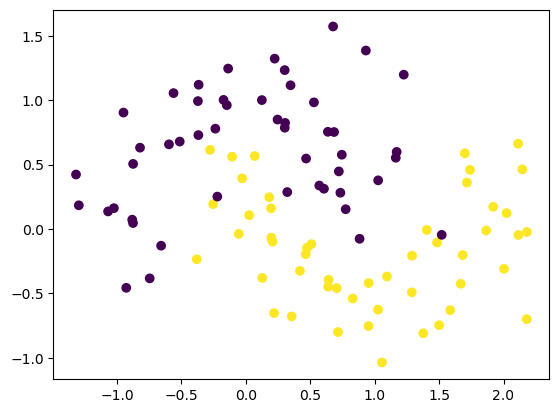

In [6]:
plt.scatter(x = df['X'], y = df['Y'], c=df['class'])

In [7]:
X = df.iloc[:, 0:2].values
y = df.iloc[:, -1].values

In [9]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [14]:
model = Sequential()

model.add(Dense(10, activation='relu', input_dim=2, kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu', kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu', kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu', kernel_initializer='he_normal'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.get_weights()

[array([[ 0.17632407, -0.78586197, -0.09937504, -1.484566  ,  0.77645165,
         -0.00454618,  0.75288105,  0.81156   ,  1.0710449 ,  0.601466  ],
        [ 0.10740937,  0.4782922 , -1.5907053 ,  1.6385523 ,  0.08852757,
         -0.49663976,  0.25586596,  0.8581187 , -1.5775093 , -0.03004257]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.19823858,  0.08159934,  0.44831428, -0.12485798,  0.19928475,
          0.02661945,  0.8042547 , -0.32746527,  0.13418743, -0.12238779],
        [ 0.38576078,  0.18033466,  0.05227779,  0.8268507 , -0.92593384,
         -0.40162092, -0.4940833 ,  0.9921087 , -0.11095126,  0.08594037],
        [ 0.22648075,  0.48347646,  0.17467117, -0.38941118,  0.1571996 ,
         -0.8472191 ,  0.59884447,  0.40194327,  0.31395274,  0.61160773],
        [ 0.34735578,  0.05099048,  0.2080079 , -0.06254426, -0.41018888,
          0.99607944,  0.47824895, -0.2503215 , -0.26701567, -0.8232293 ],
        [-0.83261

In [16]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [17]:
history = model.fit(X, y, epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 368ms/step - accuracy: 0.7595 - loss: 0.5796 - val_accuracy: 0.8500 - val_loss: 0.5519
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.7848 - loss: 0.5634 - val_accuracy: 0.8500 - val_loss: 0.5364
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.8101 - loss: 0.5501 - val_accuracy: 0.9000 - val_loss: 0.5203
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8101 - loss: 0.5374 - val_accuracy: 0.9000 - val_loss: 0.5054
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8228 - loss: 0.5243 - val_accuracy: 0.9000 - val_loss: 0.4910
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8228 - loss: 0.5122 - val_accuracy: 0.9000 - val_loss: 0.4762
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.8354 - loss: 0.5010 - val_accuracy: 0.9000 - val_loss: 0.4614
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8481 - loss: 0.4887 - val_accuracy: 0.9000 - val_loss

In [18]:
model.get_weights()

[array([[ 0.09200892, -0.82987255, -0.2267507 , -1.5958987 ,  0.7353141 ,
          0.10892455,  0.7954515 ,  0.7969358 ,  1.1417512 ,  0.6479034 ],
        [ 0.13503733,  0.48789203, -1.785326  ,  1.7231313 ,  0.06459177,
         -0.64036995,  0.16837834,  0.9412465 , -1.6102144 , -0.19389537]],
       dtype=float32),
 array([-0.0823954 , -0.12374455,  0.20969196,  0.01792298,  0.01844562,
         0.17703325,  0.11761607,  0.00440859, -0.12137245,  0.06607825],
       dtype=float32),
 array([[ 0.14471737,  0.11002378,  0.5213444 , -0.10809103,  0.13270506,
          0.08271021,  0.785978  , -0.2955129 ,  0.12454543, -0.12905483],
        [ 0.5485525 ,  0.3326971 , -0.07103879,  0.93419784, -0.8898177 ,
         -0.4693803 , -0.37529176,  0.95621485, -0.23408803,  0.034173  ],
        [ 0.29807082,  0.6392465 ,  0.40832257, -0.15378562,  0.32674697,
         -1.00089   ,  0.6468655 ,  0.33586755,  0.49213207,  0.5763495 ],
        [ 0.47298887,  0.1709854 ,  0.16696124,  0.00259217, 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 34s 4ms/step


<Axes: >

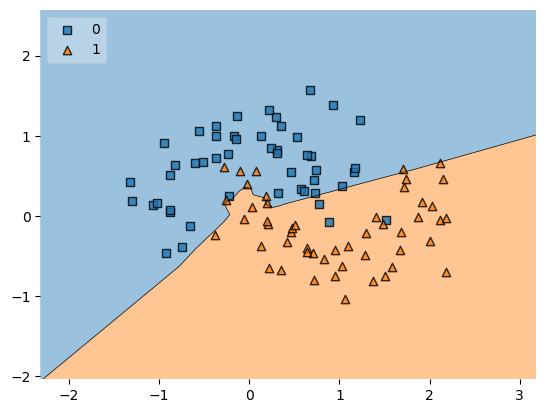

In [19]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X, y.astype(int), clf=model, legend=2)